In [4]:
from torch.utils.data import Dataset
import h5py
import torch
import numpy as np
import os
from tqdm import tqdm

class Brain2TextDS(Dataset):
    def load_h5py_file(self, file_path, day):
        data = {
            'neural_features': [],
            'n_time_steps': [],
            'seq_class_ids': [],
            'seq_len': [],
            'transcriptions': [],
            'sentence_label': [],
            'session': [],
            'block_nums': [],
            'trial_nums': [],

            'day_indicies': [],
            'features_len': [],
        }
        # Open the hdf5 file for that day
        with h5py.File(file_path, 'r') as f:
            keys = list(f.keys())
            # print(keys)
            # input("Next")
            # For each trial in the selected trials in that day
            for key in keys:
                g = f[key]

                neural_features = g['input_features'][:]
                n_time_steps = g.attrs['n_time_steps']
                seq_class_ids = g['seq_class_ids'][:] if 'seq_class_ids' in g else None
                seq_len = g.attrs['seq_len'] if 'seq_len' in g.attrs else None
                transcription = g['transcription'][:] if 'transcription' in g else None
                sentence_label = g.attrs['sentence_label'][:] if 'sentence_label' in g.attrs else None
                session = g.attrs['session']
                block_num = g.attrs['block_num']
                trial_num = g.attrs['trial_num']
                
                data['neural_features'].append(torch.tensor(neural_features, dtype=torch.float32))
                data['n_time_steps'].append(torch.tensor(n_time_steps, dtype=torch.long))
                data['seq_class_ids'].append(torch.tensor(seq_class_ids, dtype=torch.long))
                data['seq_len'].append(torch.tensor(seq_len, dtype=torch.long))
                data['transcriptions'].append(transcription)
                data['sentence_label'].append(sentence_label)
                data['session'].append(session)
                data['block_nums'].append(block_num)
                data['trial_nums'].append(trial_num)
                
                data['day_indicies'].append(torch.tensor(day, dtype=torch.long))
                data['features_len'].append(torch.tensor(neural_features.shape[0], dtype=torch.long))
                assert len(seq_class_ids) == 500
        return data
    def __init__(self, data_path, ):
        files = data_path
        files = sorted(files)
        #   'nejm-brain-to-text/data/hdf5_data_final/t15.2025.03.14/data_train.hdf5',...
    
        self.data = {
            'neural_features': [],
            'n_time_steps': [],
            'seq_class_ids': [],
            'seq_len': [],
            'transcriptions': [],
            'sentence_label': [],
            'session': [],
            'block_nums': [],
            'trial_nums': [],

            'day_indicies': [],
            'features_len': [],
        }
        for day, file in enumerate(files):
            if os.path.exists(file):
                one_day_data = self.load_h5py_file(file, day)
                for key in self.data:
                    self.data[key].extend(one_day_data[key])
        
        target_len =3000 # 最长2144，不用complie直接3000就行
        print(f"padding for target len: {target_len}")
        for i in tqdm(range(len(self.data['neural_features']))):
            nf = self.data['neural_features'][i]
            seq_len = nf.shape[0]

            if seq_len < target_len:
                pad_amount = target_len - seq_len
                nf_padded = np.pad(nf, ((0, pad_amount), (0, 0)), mode='constant', constant_values=0)
            else:
                raise ValueError(f"Sequence length {seq_len} is greater than target length {target_len}")
                # nf_padded = nf[:target_len, :]
                # assert seq_len < target_len

            # 通过索引修改原列表
            self.data['neural_features'][i] = nf_padded

        
        #print(max(self.data['neural_features']), min(self.data['neural_features']))
        # print(f"Total data size: {len(self.data['neural_features'])}")
        # # input("data")
        # maxv = 0
        # for x in self.data['neural_features']:
        #     maxv = max(maxv, x.shape[0])
        #     print(x)
        # print(maxv)
        # input("xe")
            
    
    def __len__(self):
        return len(self.data['neural_features'])
    
    def __getitem__(self, idx):
        # batch['input_features'] = pad_sequence(batch['input_features'], batch_first = True, padding_value = 0)
        # batch['seq_class_ids'] = pad_sequence(batch['seq_class_ids'], batch_first = True, padding_value = 0)

                #we need to include these keys in batch
                # features = batch['input_features'].to(self.device)
                # labels = batch['seq_class_ids'].to(self.device)
                # n_time_steps = batch['n_time_steps'].to(self.device)
                # phone_seq_lens = batch['phone_seq_lens'].to(self.device)
                # day_indicies = batch['day_indicies'].to(self.device)
        # print(self.data['neural_features'][idx].shape)
        # print(self.data['seq_class_ids'][idx].shape)
        # print(self.data['n_time_steps'][idx])
        # print(self.data['seq_len'][idx])
        # print(self.data['day_indicies'][idx])
        # print(self.data['features_len'][idx])

        return {
            'input_features': self.data['neural_features'][idx],
            'seq_class_ids': self.data['seq_class_ids'][idx],
            'n_time_steps': self.data['n_time_steps'][idx],
            'phone_seq_lens': self.data['seq_len'][idx],
            'day_indicies': self.data['day_indicies'][idx],
            'features_len': self.data['features_len'][idx],
            
            'transcriptions': self.data['transcriptions'][idx],
            # 'sentence_label': self.data['sentence_label'][idx],
            # 'session': self.data['session'][idx],
            'block_nums': self.data['block_nums'][idx],
            'trial_nums': self.data['trial_nums'][idx],
        }

padding for target len: 3000


100%|██████████| 348/348 [00:01<00:00, 335.76it/s]


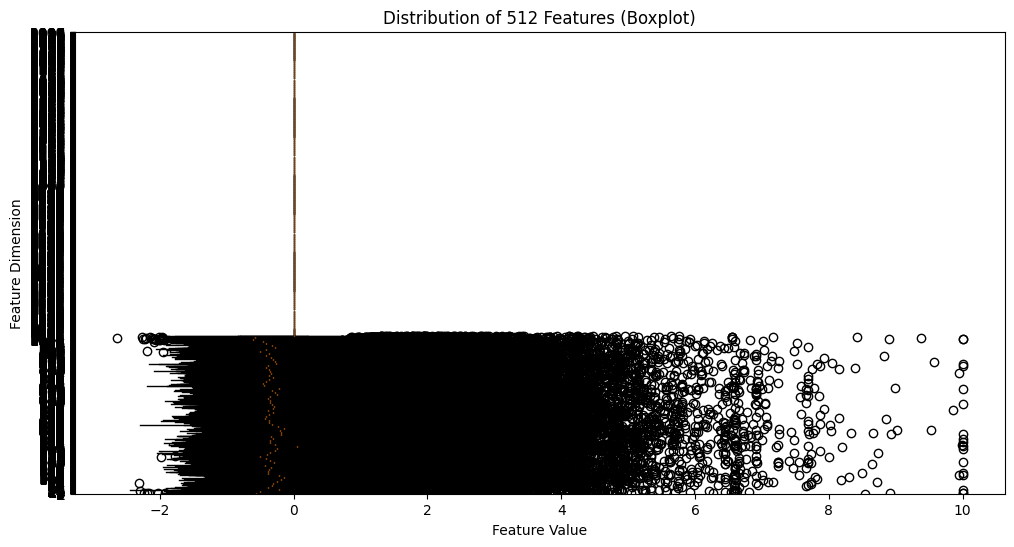

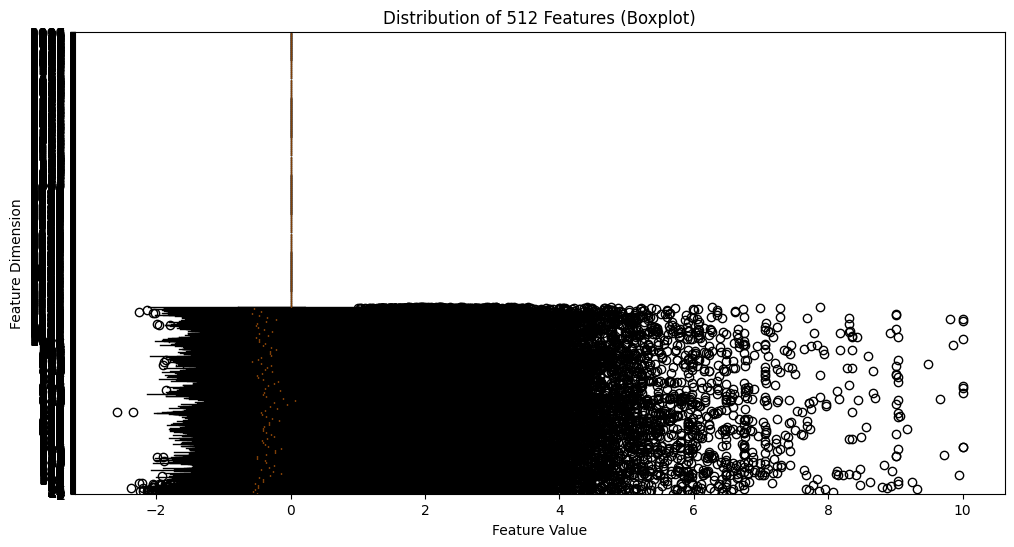

KeyboardInterrupt: 

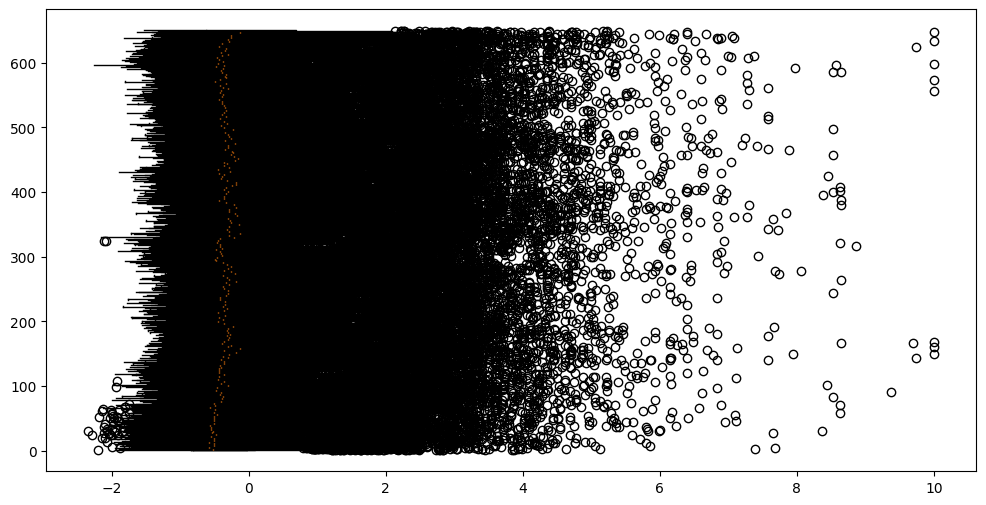

In [7]:
ds= Brain2TextDS([r'nejm-brain-to-text/data/hdf5_data_final/t15.2023.08.13/data_train.hdf5'])
from matplotlib import pyplot as plt




for i in range(len(ds)):
    dictt = ds[i]
    features = dictt['input_features']
    mean = features.mean(axis=0)  # (512,)
    std = features.mean(axis=0)   # (512,)

    # 绘制每个维度的分布（箱线图）
    plt.figure(figsize=(12, 6))
    plt.boxplot(features.T, vert=False)  # 转置为 (512, x)
    plt.xlabel("Feature Value")
    plt.ylabel("Feature Dimension")
    plt.title("Distribution of 512 Features (Boxplot)")
    plt.show()
    input("Ne")


In [11]:
# Load model directly
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer = AutoTokenizer.from_pretrained("Yangtze-flowing/phoneme2txt_v1")
model = AutoModelForSeq2SeqLM.from_pretrained("Yangtze-flowing/phoneme2txt_v1")
import torch

# 输入（假设是音素序列）
input_text = "Nihafsfsfo"   # 对应 hello
inputs = tokenizer(input_text, return_tensors="pt")
if "token_type_ids" in inputs:
    inputs.pop("token_type_ids")
# 生成
print(inputs)
# inputs = torch.rand((333, 512))
outputs = model(input_ids = inputs['input_ids'])
print(outputs[0].shape)

# 解码
decoded_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

print("Input:", input_text)
print("Output:", decoded_text)



{'input_ids': tensor([[11, 10,  3,  8, 20,  8, 20,  8, 16]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1]])}


ValueError: You have to specify either decoder_input_ids or decoder_inputs_embeds

In [ ]:
import torch
from torch import nn, optim
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# ===============================
# 1. 加载模型和tokenizer
# ===============================
model_name = "Yangtze-flowing/phoneme2txt_v1"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# ===============================
# 2. 构造一个假的batch (输入特征 + 输出文本)
# ===============================
# 输入特征 (batch_size=2, seq_len可变, feat_dim=512)
# 注意 feat_dim 必须和 model.config.d_model 一致
batch_size = 2
seq_len = 20
feat_dim = 512
X = torch.randn(batch_size, seq_len, feat_dim).to(device)

# 输出目标 (要转换成 token id)
target_texts = ["hello worsfsfld sfsf", "good sf sfsf"]
labels = tokenizer(target_texts, padding=True, return_tensors="pt").input_ids.to(device)
print(labels)

# ===============================
# 3. 定义优化器
# ===============================
optimizer = optim.AdamW(model.parameters(), lr=5e-5)

# ===============================
# 4. 前向传播 + loss
# ===============================
model.train()
outputs = model(
    inputs_embeds=X,   # 用输入特征代替 input_ids
    labels=labels,      # 目标token序列
    output_hidden_states=True,
    output_attentions=True,
)

print("Encoder hidden states layers:", len(outputs.encoder_hidden_states))  
print("Decoder hidden states layers:", len(outputs.decoder_hidden_states))  
print("Shape of one encoder layer:", outputs.decoder_hidden_states[-1].shape)
input("ne")

loss = outputs.loss
print("Loss:", loss.item())

# ===============================
# 5. 反向传播 + 参数更新
# ===============================
loss.backward()
optimizer.step()
optimizer.zero_grad()

# ===============================
# 6. 推理阶段 (不需要labels，只用generate)
# ===============================
model.eval()
with torch.no_grad():
    generated = model.generate(inputs_embeds=X, max_new_tokens=20)
    decoded = tokenizer.batch_decode(generated, skip_special_tokens=True)

print("Decoded:", decoded)


tensor([[10,  7, 13, 13, 16, 61, 16, 19, 20,  8, 20,  8, 13,  6, 38,  8, 20,  8],
        [ 9, 16, 16,  6, 38,  8, 38,  8, 20,  8, 89, 89, 89, 89, 89, 89, 89, 89]],
       device='cuda:0')


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Encoder hidden states layers: 7
Decoder hidden states layers: 7
Shape of one encoder layer: torch.Size([2, 18, 512])
